## Lab 4: Part 1 (binclass)

## Import Required Libraries



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
import pandas as pd
from matplotlib.colors import ListedColormap
from math import sqrt,pi

## Load and Explore the Data

Load the binary classification data from 'binclass.txt'. The file contains comma-separated values where:
- The first two columns are features (x)
- The third column is the class label (y)

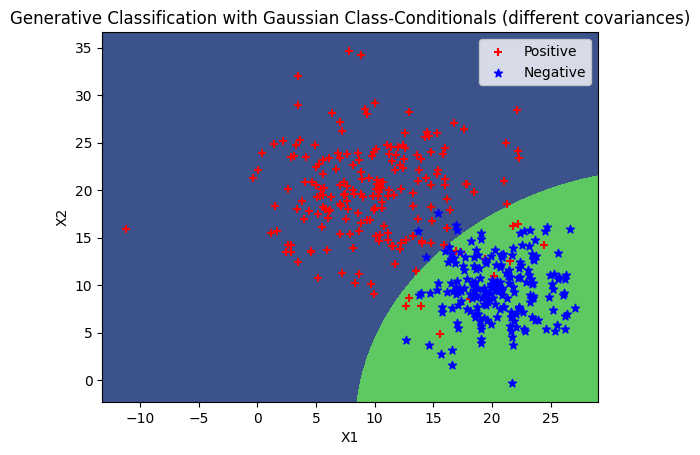

In [ ]:
# TODO: Load data from 'binclass.txt' using np.loadtxt with delimiter=","
#data = np.loadtxt("/content/binclass.txt", delimiter=",")
# reading the file
with open('binclass.txt') as f:
  df = pd.read_csv(f, header=None)
#seperating +ve and -ve
positive = df.loc[df[2] == 1].iloc[: , :2]
negative = df.loc[df[2] == -1].iloc[: , :2]

#function to get mean and covariance
def get_mean(data):
  return np.array(data.mean(axis=0))
def get_variance(data):
  return np.array(data.std(axis = 0)).mean()

#get required mean and covariance
mu_positive = get_mean(positive)
mu_negative = get_mean(negative)
sigma_positive = get_variance(positive)
sigma_negative = get_variance(negative)


# plotting Generative Classification with Gaussian Class-Conditionals (different covariances)

X, Y = np.meshgrid( np.arange(min(df[0])-2, max(df[0])+2, 0.05),np.arange(min(df[1])-2, max(df[1])+2, 0.05))
D=2
Z_pos = ((1/ pow(sqrt(2*pi),D)*sigma_positive))*np.exp(-(((X - mu_positive[0])**2 + (Y - mu_positive[1])**2) /(2*sigma_positive)))
Z_neg = ((1/ pow(sqrt(2*pi),D)*sigma_negative))*np.exp(-(((X - mu_negative[0])**2 + (Y - mu_negative[1])**2) /(2*sigma_negative)))
plt.contourf(X,Y,Z_neg-Z_pos,0)
plt.scatter(positive[0], positive[1], color = 'red', label = 'Positive',marker='+')
plt.scatter(negative[0], negative[1], color = 'blue', label = 'Negative',marker='*')
label = ['Decision Boundary']
plt.title('Generative Classification with Gaussian Class-Conditionals (different covariances)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()


## Lab 4: Part 1
## same coveriance
N(x∣μ−​,σ^2I2​)

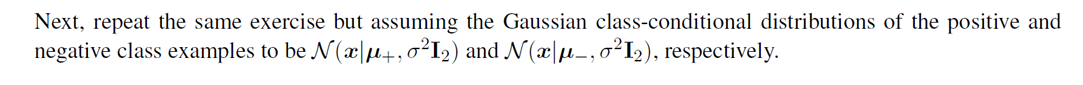

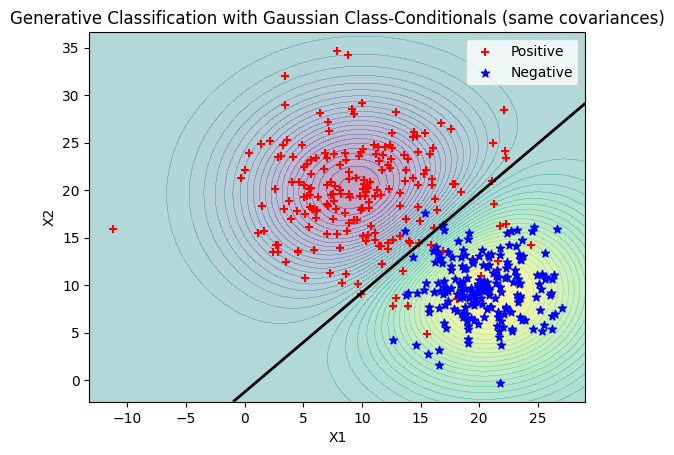

In [ ]:


# 1) Read data
df = pd.read_csv('binclass.txt', header=None, sep=',')

# 2) Separate classes
positive = df[df[2] == 1].iloc[:, :2].to_numpy()
negative = df[df[2] == -1].iloc[:, :2].to_numpy()


mu_pos = positive.mean(axis=0)
mu_neg = negative.mean(axis=0)

D = 2

# combine both classes
Xall = np.vstack([positive, negative])

# pooled variance (scalar)
sigma2 = Xall.var(axis=0, ddof=0).mean()


Z_pos = (1 / ((2*np.pi*sigma2)**(D/2))) * \
        np.exp(-(((X-mu_pos[0])**2 + (Y-mu_pos[1])**2) / (2*sigma2)))

Z_neg = (1 / ((2*np.pi*sigma2)**(D/2))) * \
        np.exp(-(((X-mu_neg[0])**2 + (Y-mu_neg[1])**2) / (2*sigma2)))


plt.contourf(X, Y, Z_neg - Z_pos, levels=50, alpha=0.35)
plt.contour(X, Y, Z_neg - Z_pos, levels=[0], colors='k', linewidths=2)

plt.scatter(positive[:,0], positive[:,1], color='red', label='Positive', marker='+')
plt.scatter(negative[:,0], negative[:,1], color='blue', label='Negative', marker='*')

plt.title('Generative Classification with Gaussian Class-Conditionals (same covariances)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


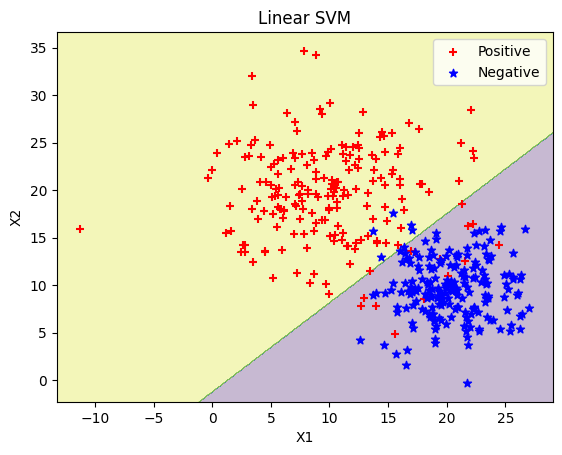

In [ ]:
X_set, y_set = df.iloc[:, [0, 1]].values, df.iloc[:, [2]].values

from sklearn.svm import SVC
classifier = SVC(C = 1, kernel = 'linear', random_state = 0)
classifier.fit(X_set, y_set)
plt.contourf(X, Y, classifier.predict(np.array([X.ravel(), Y.ravel()]).T).reshape(X.shape), alpha = 0.3)

plt.scatter(positive[0], positive[1], color = 'red', label = 'Positive',marker='+')
plt.scatter(negative[0], negative[1], color = 'blue', label = 'Negative',marker='*')

# Plot Contour
plt.title('Linear SVM')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

##Lab 4: Part 2 (binclassv2)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap
from math import sqrt,pi


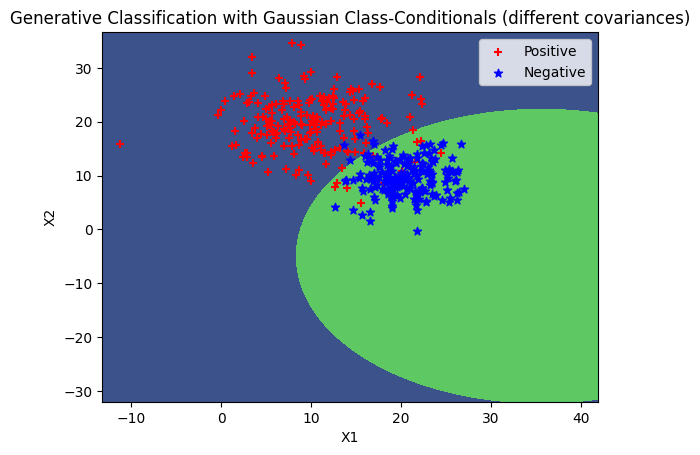

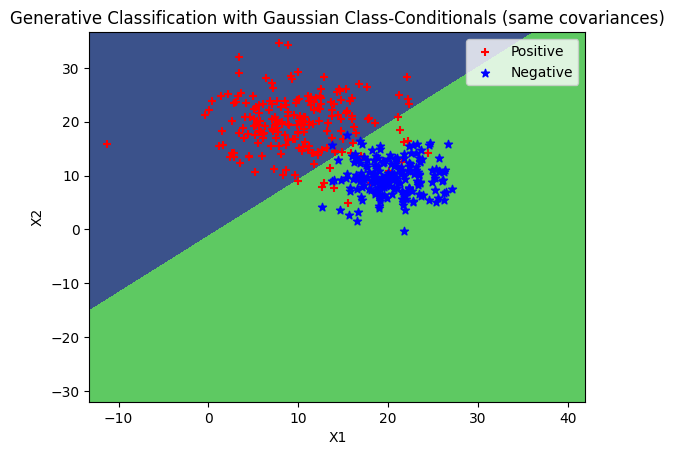

In [ ]:
# reading the file
with open('binclassv2.txt') as f:
  df = pd.read_csv(f, header=None)

#seperating positive and negative classes
pos = df.loc[df[2] == 1].iloc[:,:2]
neg = df.loc[df[2] == -1].iloc[:,:2]



# helper function to get mean and covaariance
def get_mean(data):
  return np.array(data.mean(axis = 0))
def get_variance(data):
  return np.array(data.std(axis = 0)).mean()



#get required mean and covariance
mu_positive = get_mean(positive)
mu_negative = get_mean(negative)
sigma_positive = get_variance(positive)
sigma_negative = get_variance(negative)

X, Y = np.meshgrid( np.arange(min(df[0])-2, max(df[0])+2, 0.05),np.arange(min(df[1])-2, max(df[1])+2, 0.05))
D=2
Z_pos = ((1/ pow(sqrt(2*pi),D)*sigma_positive))*np.exp(-(((X - mu_positive[0])**2 + (Y - mu_positive[1])**2) /(2*sigma_positive)))
Z_neg = ((1/ pow(sqrt(2*pi),D)*sigma_negative))*np.exp(-(((X - mu_negative[0])**2 + (Y - mu_negative[1])**2) /(2*sigma_negative)))
plt.contourf(X,Y,Z_neg-Z_pos,0)
plt.scatter(positive[0], positive[1], color = 'red', label = 'Positive',marker='+')
plt.scatter(negative[0], negative[1], color = 'blue', label = 'Negative',marker='*')
label = ['Decision Boundary']
plt.title('Generative Classification with Gaussian Class-Conditionals (different covariances)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

sigma =sigma_positive + sigma_negative
D=2
Z_pos = ((1/ pow(sqrt(2*pi),D)*sigma))*np.exp(-(((X - mu_positive[0])**2 + (Y - mu_positive[1])**2) /(2*sigma)))
Z_neg = ((1/ pow(sqrt(2*pi),D)*sigma))*np.exp(-(((X - mu_negative[0])**2 + (Y - mu_negative[1])**2) /(2*sigma)))
plt.contourf(X,Y,Z_neg-Z_pos,0)
plt.scatter(positive[0], positive[1], color = 'red', label = 'Positive',marker='+')
plt.scatter(negative[0], negative[1], color = 'blue', label = 'Negative',marker='*')
label = ['Decision Boundary']
plt.title('Generative Classification with Gaussian Class-Conditionals (same covariances)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


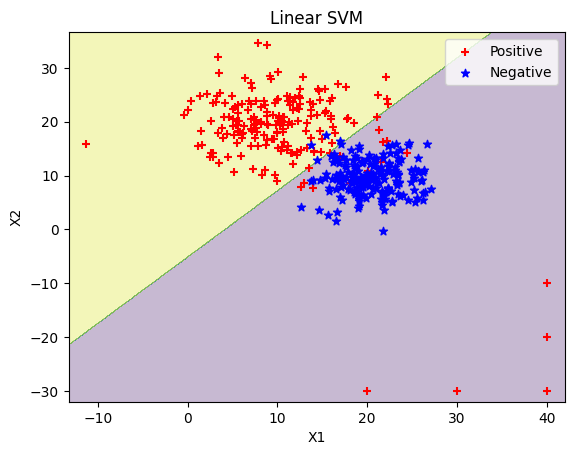

In [ ]:

X_set, y_set = df.iloc[:, [0, 1]].values, df.iloc[:, [2]].values

from sklearn.svm import SVC
classifier = SVC(C = 1, kernel = 'linear', random_state = 0)
classifier.fit(X_set, y_set)
plt.contourf(X, Y, classifier.predict(np.array([X.ravel(), Y.ravel()]).T).reshape(X.shape), alpha = 0.3)

plt.scatter(pos[0], pos[1], color = 'red', label = 'Positive',marker='+')
plt.scatter(neg[0], neg[1], color = 'blue', label = 'Negative',marker='*')

plt.title('Linear SVM')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()


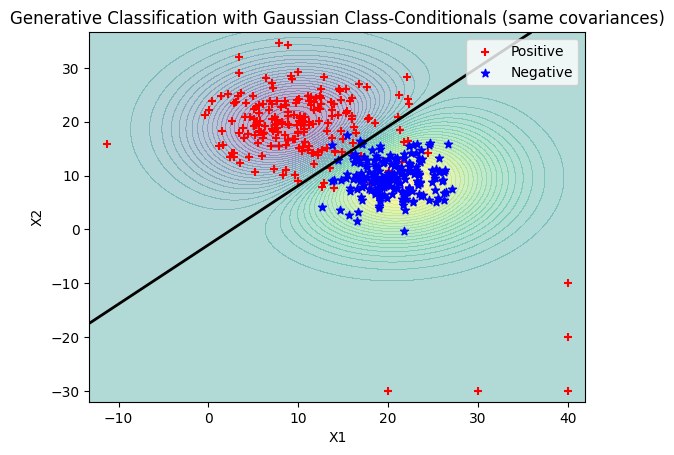

In [ ]:


# 1) Read data
df = pd.read_csv('binclassv2.txt', header=None, sep=',')

# 2) Separate classes
positive = df[df[2] == 1].iloc[:, :2].to_numpy()
negative = df[df[2] == -1].iloc[:, :2].to_numpy()


mu_pos = positive.mean(axis=0)
mu_neg = negative.mean(axis=0)

D = 2

# combine both classes
Xall = np.vstack([positive, negative])

# pooled variance (scalar)
sigma2 = Xall.var(axis=0, ddof=0).mean()


Z_pos = (1 / ((2*np.pi*sigma2)**(D/2))) * \
        np.exp(-(((X-mu_pos[0])**2 + (Y-mu_pos[1])**2) / (2*sigma2)))

Z_neg = (1 / ((2*np.pi*sigma2)**(D/2))) * \
        np.exp(-(((X-mu_neg[0])**2 + (Y-mu_neg[1])**2) / (2*sigma2)))


plt.contourf(X, Y, Z_neg - Z_pos, levels=50, alpha=0.35)
plt.contour(X, Y, Z_neg - Z_pos, levels=[0], colors='k', linewidths=2)

plt.scatter(positive[:,0], positive[:,1], color='red', label='Positive', marker='+')
plt.scatter(negative[:,0], negative[:,1], color='blue', label='Negative', marker='*')

plt.title('Generative Classification with Gaussian Class-Conditionals (same covariances)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()